# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who = The audience of this dataset is primarily credit lenders who desire to look at transaction trends of their consumers in order to predict if there will be a default on their credit loan. 

What = The insitiution wants to know if an indiviudal is at risk of a default based on their transaction characteristics and lending history. They want to identify factors that most correlate with a defaulted transaction. The target variable is the default payment next month. The goal is to identify whuch customer characteristics and payment behaviors are most associated with default risk so the lendor can make better credit risk decisions. 

How = Use clear charts and models to show patterns in repayment history, credit limits, bill ammounts and credit behavior. Utilize logistic regression to prdict the probabilty of default (target variable) based on the feature variables in the dataset. This will help explain which variables increase or decrease credit risk in the dataset. I will look at the logistic regression coefficients to identify the leading contributor to default. 


I will also utilize the random forrest model as it is a machine learning model that can use many decision trees to make a prediction of defaults. This approach is useful fdor the credit card default set because default may depend on many compounding factors of consumer behavior such as repayment history, bill ammounts, payment ammounts, and credit limit. Feature importance from a random forrest also predict which variable is the strongest contributor to defaults.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

## ALL LENDING CLUB LOAN DATA ##

In [2]:
# LOADING THE DATASETS 

DATA_DIR = Path("/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/All Lending Club Loan Data")

Accepted_Lending_Club_Data= pd.read_csv(DATA_DIR / "accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", encoding="latin1")
Rejected_Lending_Club_Data = pd.read_csv(DATA_DIR / "rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv")


/var/folders/mv/spx6wvr963x933gjcq0392n80000gn/T/ipykernel_53876/1348182421.py:5: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  Accepted_Lending_Club_Data= pd.read_csv(DATA_DIR / "accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", encoding="latin1")


In [3]:
# ALL LENDING CLUB LOAN DATA


# ACCEPTED DATASET
# Displaying info and describing the dataset
Accepted_Lending_Club_Data.info()
Accepted_Lending_Club_Data.describe()

# # Mean, median, mode 
Accepted_Lending_Club_Data.mean(numeric_only = True)
Accepted_Lending_Club_Data.median(numeric_only = True) 
Accepted_Lending_Club_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Accepted_Lending_Club_Data.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

# data.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 
Accepted_Lending_Club_Data.isnull().any().sum() # there are 150 null values in the dataset



# REJECTED DATASET 
# Displaying info and describing the dataset
Rejected_Lending_Club_Data.info()
Rejected_Lending_Club_Data.describe()

# # Mean, median, mode 
Rejected_Lending_Club_Data.mean(numeric_only = True)
Rejected_Lending_Club_Data.median(numeric_only = True) 
Rejected_Lending_Club_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Rejected_Lending_Club_Data.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

# data.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 
Rejected_Lending_Club_Data.isnull().any().sum() # there are 150 null values in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 3.0+ GB
<class 'pandas.DataFrame'>
RangeIndex: 27648741 entries, 0 to 27648740
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      str    
 2   Loan Title            str    
 3   Risk_Score            float64
 4   Debt-To-Income Ratio  str    
 5   Zip Code              str    
 6   State                 str    
 7   Employment Length     str    
 8   Policy Code           float64
dtypes: float64(3), str(6)
memory usage: 3.0 GB


np.int64(6)

In [18]:

Accepted_Lending_Club_Data

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
Rejected_Lending_Club_Data


,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0
...,...,...,...,...,...,...,...,...,...
27648736,10000.0,2016-12-31,Debt consolidation,590.0,41.26%,441xx,OH,< 1 year,0.0
27648737,10000.0,2016-12-31,moving,NaN,1.48%,207xx,MD,5 years,0.0
27648738,1200.0,2016-12-31,Other,686.0,10.26%,914xx,CA,< 1 year,0.0
27648739,25000.0,2016-12-31,debt_consolidation,NaN,17.71%,880xx,NM,< 1 year,0.0


##  HOME CREDIT DEFAULT RISK DATASET ## 

## Data set Descriptions for Home Credit Default Risk ##

application_train.csv
This is the main dataset for analysis. Includes the target column

HomeCredit_columns_description.csv
Data dictionary. Helps explain weird column names.

bureau.csv
Previous credit history from other banks/lenders.

previous_application.csv
Previous Home Credit applications.

installments_payments.csv
Payment history on previous Home Credit loans.

credit_card_balance.csv
Credit card balance history.

POS_CASH_balance.csv
Monthly balance history for point-of-sale/cash loans.

bureau_balance.csv
Monthly history for bureau records.

sample_submission.csv
Only for Kaggle competition formatting.

In [5]:

DATA_DIR = Path("/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/home-credit-default-risk")

Home_Credit_app = pd.read_csv(DATA_DIR / 'previous_application.csv')
Home_Credit_app_TEST = pd.read_csv(DATA_DIR / 'application_test.csv')
Home_Credit_app_TRAIN = pd.read_csv(DATA_DIR / 'application_train.csv') # this is the main analysis dataset in the material 

Home_Credit_bureau = pd.read_csv(DATA_DIR / "bureau.csv")
Home_Credit_credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
Home_Credit_POS_CASH_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")


In [ ]:
# Home Credit App_TRAIN (Main Dataset for Analysis)

# Data types and describing the data 
Home_Credit_app_TRAIN.info()
Home_Credit_app_TRAIN.describe()
Home_Credit_app_TRAIN.shape # dataset has 307511 rows and 122 columns 



# # Mean, median, mode 
Home_Credit_app_TRAIN.mean(numeric_only = True)
Home_Credit_app_TRAIN.median(numeric_only = True) 
Home_Credit_app_TRAIN.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Home_Credit_app_TRAIN.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

# Home_Credit_app_TRAIN.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 
Home_Credit_app_TRAIN.isnull().any().sum() # there are 67 null values in the dataset








<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


np.False_

(307511, 122)

## LOAN DEFAULT DATA ##

In [14]:
Loan_Default_Data = pd.read_csv('/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/Loan_Default.csv')

In [15]:
# Loan Default Data 

# Data types and describing the data 
Loan_Default_Data.info()
Loan_Default_Data.describe()

# # Mean, median, mode 
Loan_Default_Data.mean(numeric_only = True)
Loan_Default_Data.median(numeric_only = True) 
Loan_Default_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Loan_Default_Data.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

# data.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 
Loan_Default_Data.isnull().any().sum() # there are 150 null values in the dataset


<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

np.int64(14)

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

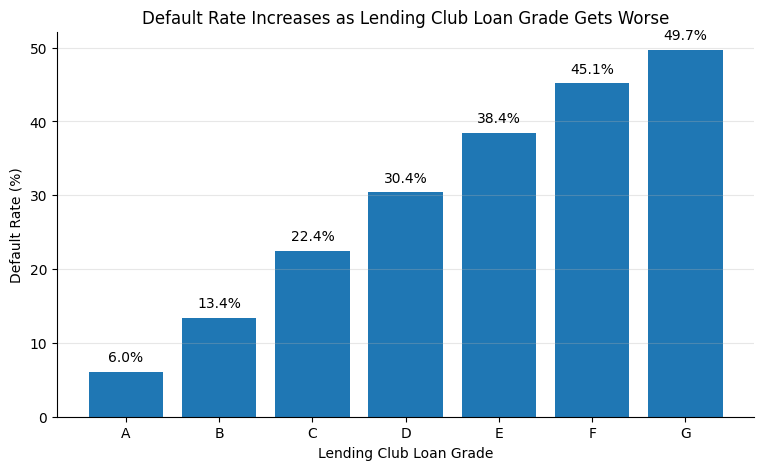

In [ ]:

data = Accepted_Lending_Club_Data.copy()


# Looking if Grades of Loans Affect the Loan Default Risk

# Keep loans with a clear final outcome
finished_loans = data[data["loan_status"].isin([
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
])].copy()

# Create default flag
finished_loans["defaulted"] = finished_loans["loan_status"].isin([
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]).astype(int)

# Calculate default rate by loan grade
default_by_grade = (
    finished_loans.groupby("grade")["defaulted"]
    .mean()
    .reset_index()
)

# Convert default rate to percent
default_by_grade["default_rate_percent"] = default_by_grade["defaulted"] * 100

# Sort grades in order
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
default_by_grade["grade"] = pd.Categorical(
    default_by_grade["grade"],
    categories=grade_order,
    ordered=True
)
default_by_grade = default_by_grade.sort_values("grade")

# Create the bar chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    default_by_grade["grade"],
    default_by_grade["default_rate_percent"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Default Rate Increases as Lending Club Loan Grade Gets Worse")
plt.xlabel("Lending Club Loan Grade")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()